## HUG-IML Modeling Special Cases
### Multiclass outcomes, imbalanced labels, high-cardinality categoricals, adaptive binning, and governed pattern pruning.

This notebook demonstrates practical modeling scenarios that often create implementation errors in tabular interpretable modeling. Each section uses bounded, local data and keeps transformations inside the training workflow or fits encoders on training data only.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score

from hugiml import HUGIMLClassifier
from hugiml.multiclass import MulticlassHUGReport, make_imbalanced_pipeline, encode_high_cardinality, apply_encoding
from hugiml.adaptive import HUGIMLAdaptive
from hugiml.pruning import PatternEditor

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 110)

## 1. Multiclass classification

HUG-IML can expose class-specific pattern contributions. The iris dataset keeps the demonstration compact.

In [2]:
iris = load_iris(as_frame=True)
X_mc = iris.data.copy()
y_mc = pd.Series(iris.target, name="species")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_mc, y_mc, test_size=0.25, stratify=y_mc, random_state=RANDOM_STATE
)
clf_mc = HUGIMLClassifier(B=5, L=2, G=1e-3, topK=50)
clf_mc.fit(X_tr, y_tr)
preds = clf_mc.predict(X_te)
print(classification_report(y_te, preds, target_names=iris.target_names))

report = MulticlassHUGReport(clf_mc)
print(report.summary(top_n=5))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.85      0.85      0.85        13
   virginica       0.85      0.85      0.85        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.89      0.89      0.89        38

MulticlassHUGReport

Class: 0
----------------------------------------
  sepal width (cm)=[2,2.7)                  coef= -1.1901  sup=0.143
  sepal width (cm)=[3.4,4.4)                coef= +1.0913  sup=0.250
  sepal length (cm)=[4.3,5.02)              coef= +0.9612  sup=0.205
  petal width (cm)=[0.2,1.14)               coef= +0.8179  sup=0.357
  petal length (cm)=[1.1,1.5)               coef= +0.8112  sup=0.152

Class: 1
----------------------------------------
  petal length (cm)=[3.9,4.66)              coef= +1.2600  sup=0.205
  petal width (cm)=[1.14,1.5)               coef= +1.1042  sup=0.188
  sepal width 

## 2. Imbalanced binary data

The balanced wrapper is compared with a plain HUG-IML fit using the same split.

In [3]:
X_imb_arr, y_imb = make_classification(
    n_samples=1800,
    n_features=15,
    n_informative=8,
    n_redundant=3,
    weights=[0.90, 0.10],
    class_sep=0.85,
    flip_y=0.02,
    random_state=RANDOM_STATE,
)
X_imb = pd.DataFrame(X_imb_arr, columns=[f"signal_{i:02d}" for i in range(X_imb_arr.shape[1])])
X_tr, X_te, y_tr, y_te = train_test_split(
    X_imb, y_imb, test_size=0.25, stratify=y_imb, random_state=RANDOM_STATE
)

plain = HUGIMLClassifier(B=6, L=2, G=5e-3, topK=80)
plain.fit(X_tr, y_tr)
plain_pred = plain.predict(X_te)
plain_score = plain.predict_proba(X_te)[:, 1]

balanced = make_imbalanced_pipeline(HUGIMLClassifier(B=6, L=2, G=5e-3, topK=80), strategy="class_weight")
balanced.fit(X_tr, y_tr)
bal_pred = balanced.predict(X_te)
bal_score = balanced.predict_proba(X_te)[:, 1]

imb_summary = pd.DataFrame([
    {"model": "Plain HUG-IML", "balanced_accuracy": balanced_accuracy_score(y_te, plain_pred), "roc_auc": roc_auc_score(y_te, plain_score)},
    {"model": "Balanced HUG-IML", "balanced_accuracy": balanced_accuracy_score(y_te, bal_pred), "roc_auc": roc_auc_score(y_te, bal_score)},
])
imb_summary

,model,balanced_accuracy,roc_auc
0,Plain HUG-IML,0.561256,0.666045
1,Balanced HUG-IML,0.631530,0.659619


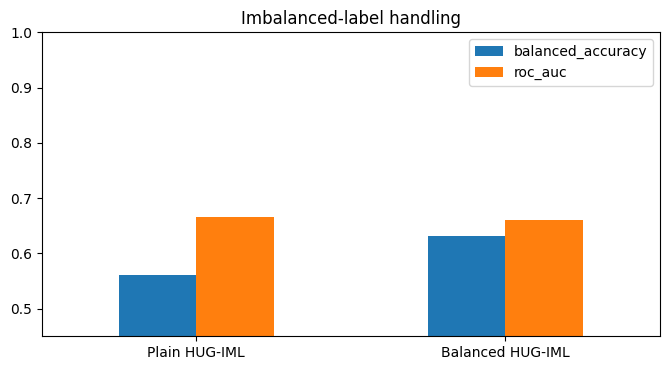

In [4]:
fig, ax = plt.subplots(figsize=(6.8, 3.8))
imb_summary.set_index("model")[["balanced_accuracy", "roc_auc"]].plot(kind="bar", ax=ax)
ax.set_ylim(0.45, 1.0)
ax.set_title("Imbalanced-label handling")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. High-cardinality categorical feature

The city encoder is fitted only on the training split and then applied to the test split. This avoids target leakage.

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
n = 1800
cities = [f"city_{i:04d}" for i in range(520)]
X_hc = pd.DataFrame({
    "city": rng.choice(cities, n),
    "age": rng.integers(18, 72, n),
    "income": rng.exponential(42000, n),
    "product": rng.choice(["A", "B", "C", "D", "E"], n),
})
city_suffix = X_hc["city"].str[-2:].astype(int)
y_hc = ((X_hc["income"] > 45000) & (X_hc["age"] > 36) | (city_suffix < 12)).astype(int).to_numpy()

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_hc, y_hc, test_size=0.25, stratify=y_hc, random_state=RANDOM_STATE
)
X_tr_enc, enc_map = encode_high_cardinality(X_tr_raw, y_tr, threshold=12, method="target_mean")
X_te_enc = apply_encoding(X_te_raw, enc_map)

cat_cols = X_tr_enc.select_dtypes(include=["object", "category"]).columns.tolist()
int_cols = X_tr_enc.select_dtypes(include=["int", "int32", "int64"]).columns.tolist()
flt_cols = [c for c in X_tr_enc.columns if c not in cat_cols + int_cols]

hc = HUGIMLClassifier(
    allCols=[int_cols, flt_cols, cat_cols],
    origColumns=X_tr_enc.columns.tolist(),
    B=6,
    L=2,
    G=5e-3,
    topK=80,
)
hc.fit(X_tr_enc, y_tr)
hc_score = hc.predict_proba(X_te_enc)[:, 1]
print(f"Unique cities in raw data: {X_hc['city'].nunique():,}")
print(f"Encoded city map entries fitted on training data: {len(enc_map['city']):,}")
print(f"High-cardinality ROC-AUC: {roc_auc_score(y_te, hc_score):.3f}")
hc.get_pattern_info().merge(hc.feature_importances()[["pattern", "coefficient", "abs_coefficient"]], on="pattern").sort_values("abs_coefficient", ascending=False).head(10)

Unique cities in raw data: 503
Encoded city map entries fitted on training data: 487
High-cardinality ROC-AUC: 0.890


,pattern,utility,information_gain,support,coefficient,abs_coefficient
15,"city=[0.3665,0.9879)",258.000000,0.183552,0.1911,3.947815,3.947815
14,"income=[4.565e+04,7.506e+04)",142.891875,0.112028,0.1667,2.449282,2.449282
13,"income=[7.506e+04,3.998e+05)",86.511600,0.067826,0.1667,2.108693,2.108693
5,"income=[7.898,7107)",2.359350,0.036995,0.1667,-1.998561,1.998561
4,"age=[18,27)",1.923712,0.030258,0.1659,-1.510767,1.510767
12,"city=[0.3313,0.3665)",59.847738,0.049901,0.1526,1.504291,1.504291
3,"income=[7107,1.679e+04)",1.592775,0.024976,0.1667,-1.438361,1.438361
1,"income=[2.972e+04,4.565e+04)",1.430100,0.022425,0.1667,-1.413058,1.413058
7,"city=[0.08765,0.263)",3.173388,0.053829,0.1489,-1.361225,1.361225
2,"income=[1.679e+04,2.972e+04)",1.510200,0.023680,0.1667,-1.272285,1.272285


## 4. Adaptive binning

Adaptive binning lets the model choose feature-level bin counts from a candidate list.

In [6]:
adapt = HUGIMLAdaptive(b_candidates=[3, 5, 7, 10], L=2, G=5e-3)
adapt.fit(X_tr_enc, y_tr)
adapt_score = adapt.predict_proba(X_te_enc)[:, 1]
print(f"Adaptive HUG-IML ROC-AUC: {roc_auc_score(y_te, adapt_score):.3f}")
chosen_bins = pd.DataFrame(sorted(adapt.per_feature_b_.items()), columns=["feature", "chosen_B"])
chosen_bins

Adaptive HUG-IML ROC-AUC: 0.862


,feature,chosen_B
0,age,5
1,city,3
2,income,3


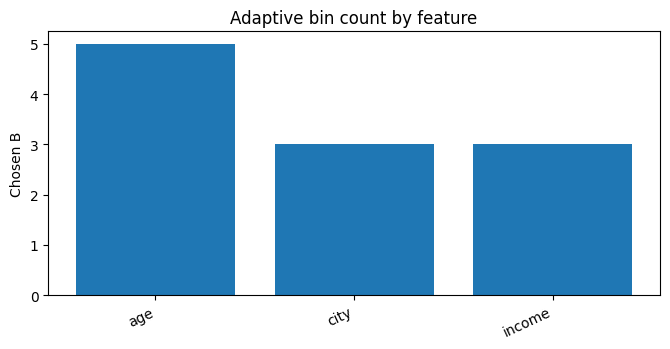

In [7]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.bar(chosen_bins["feature"], chosen_bins["chosen_B"])
ax.set_title("Adaptive bin count by feature")
ax.set_ylabel("Chosen B")
ax.set_xlabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 5. Governed pattern pruning

The editor creates an audit trail for low-support pattern removal, downstream refitting, and probability calibration.

In [8]:
editor = PatternEditor(hc, operator_name="model_risk_reviewer")
before = editor.diff()["n_original"]
editor.remove_low_support(min_support=0.02, reason="low support relative to review threshold")
after = editor.diff()["n_current"]
editor.refit(X_tr_enc, y_tr)
editor.calibrate(X_te_enc, y_te, method="isotonic")
pruned = editor.finalize()
pruned_score = pruned.predict_proba(X_te_enc)[:, 1]

print(f"Patterns before pruning: {before}")
print(f"Patterns after pruning: {after}")
print(f"Pruned calibrated ROC-AUC: {roc_auc_score(y_te, pruned_score):.3f}")
print(editor.audit_report())

Patterns before pruning: 16
Patterns after pruning: 16
Pruned calibrated ROC-AUC: 0.913
{
  "operator": "model_risk_reviewer",
  "generated_at": "2026-05-26T02:26:56.493432",
  "diff": {
    "n_original": 16,
    "n_current": 16,
    "n_removed": 0,
    "removed_patterns": []
  },
  "calibration": {
    "applied": true,
    "method": "isotonic"
  },
  "removals": []
}


These scenarios are manageable when data preparation is fold-safe, high-cardinality transformations are fitted only on training data, and pattern-editing decisions are retained as auditable model governance evidence.